# Arabic Conversational AI: Standard vs Dynamic Transformer Comparison

This notebook compares a **Standard Transformer** with a **Dynamic Neural Network-Enhanced Transformer** for Arabic conversational AI.

## Goals
1. Generate ~5,00 Arabic conversational samples (greetings, Q&A, basic tasks)
2. Train a standard pure-Python transformer as baseline
3. Train a Dynamic NN transformer with adaptive architecture
4. Compare performance, efficiency, and architecture evolution

## Table of Contents
1. [Setup and Imports](#1-setup)
2. [Data Generation](#2-data)
3. [Data Exploration](#3-explore)
4. [Tokenization](#4-tokenize)
5. [Standard Transformer](#5-standard)
6. [Dynamic Transformer](#6-dynamic)
7. [Comparison](#7-comparison)
8. [Architecture Evolution](#8-architecture)
9. [Health Analysis](#9-health)
10. [Demo](#10-demo)
11. [Conclusions](#11-conclusions)

## 1. Setup and Imports <a id='1-setup'></a>

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add parent directory to path for imports
notebook_dir = Path(os.getcwd()).parent if 'data' in os.getcwd() else Path(os.getcwd())
sys.path.insert(0, str(notebook_dir))

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Configure matplotlib for Arabic text
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"NumPy version: {np.__version__}")
print(f"Working directory: {os.getcwd()}")

NumPy version: 2.4.0
Working directory: c:\Workspaces\dynamic_nn\notebooks\arabic_transformer\data


In [2]:
# Import our modules (with reload to pick up any changes)
import importlib
import src.arabic_data_generator
import src.arabic_tokenizer
import src.standard_transformer
import src.dynamic_transformer
import src.comparison_evaluator

# Reload all modules to ensure latest code
importlib.reload(src.arabic_data_generator)
importlib.reload(src.arabic_tokenizer)
importlib.reload(src.standard_transformer)
importlib.reload(src.dynamic_transformer)
importlib.reload(src.comparison_evaluator)

from src.arabic_data_generator import ArabicConversationalGenerator, generate_dataset
from src.arabic_tokenizer import ArabicTokenizer, TokenizerConfig, create_tokenizer_from_samples
from src.standard_transformer import StandardTransformer, TransformerConfig
from src.dynamic_transformer import DynamicTransformer, DynamicTransformerConfig
from src.comparison_evaluator import TransformerComparisonEvaluator, ComparisonMetrics

print("All modules imported and reloaded successfully!")

All modules imported and reloaded successfully!


## 2. Arabic Conversational Data Generation <a id='2-data'></a>

Generate ~5,000 Arabic conversational samples across 8 categories:
- Greetings
- Personal Information
- Time/Date
- Location
- Weather
- Calculations
- General Information
- Code-switching (Arabic-English mixed)

In [3]:
# Generate dataset
data_size = 500

generator = ArabicConversationalGenerator(seed=SEED)
samples = generator.generate_samples(num_samples=data_size)

# Get statistics
stats = generator.get_statistics()
print(f"\nDataset Statistics:")
print(f"  Total samples: {stats['total_samples']}")
print(f"  Unique inputs: {stats['unique_inputs']}")
print(f"  Unique outputs: {stats['unique_outputs']}")
print(f"  Avg input length: {stats['avg_input_length']:.1f} chars")
print(f"  Avg output length: {stats['avg_output_length']:.1f} chars")


Dataset Statistics:
  Total samples: 500
  Unique inputs: 217
  Unique outputs: 251
  Avg input length: 14.4 chars
  Avg output length: 14.8 chars


In [4]:
# Split into train/val/test
train_samples, val_samples, test_samples = generator.split_data(
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)

print(f"Train: {len(train_samples)} samples")
print(f"Val:   {len(val_samples)} samples")
print(f"Test:  {len(test_samples)} samples")

Train: 400 samples
Val:   50 samples
Test:  50 samples


## 3. Data Exploration <a id='3-explore'></a>

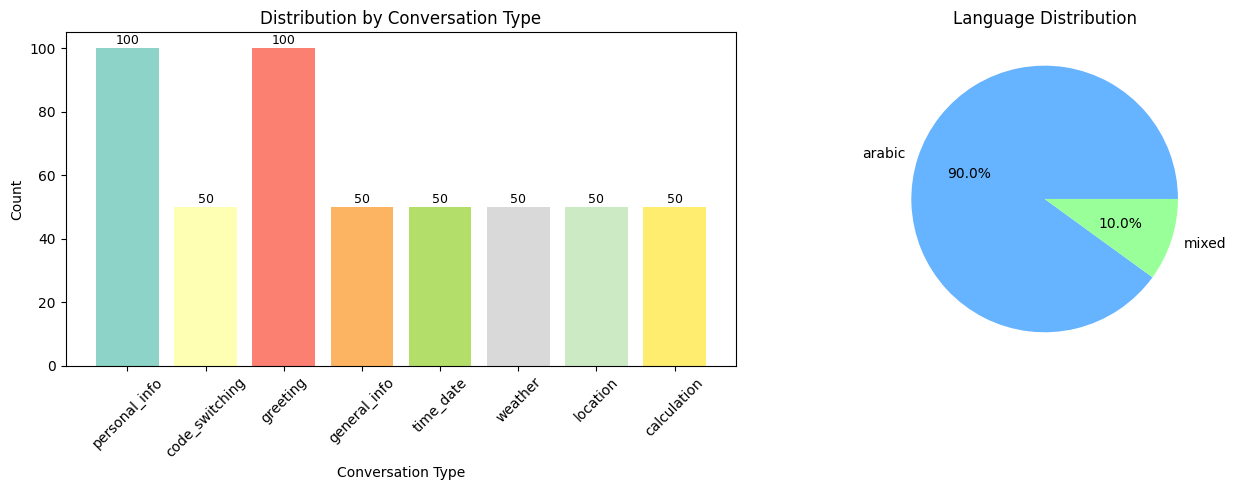

In [5]:
# Type distribution
type_counts = stats['type_distribution']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conversation type distribution
ax1 = axes[0]
types = list(type_counts.keys())
counts = list(type_counts.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(types)))
bars = ax1.bar(types, counts, color=colors)
ax1.set_xlabel('Conversation Type')
ax1.set_ylabel('Count')
ax1.set_title('Distribution by Conversation Type')
ax1.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts):
    ax1.annotate(f'{count}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Language distribution
ax2 = axes[1]
lang_counts = stats['language_distribution']
ax2.pie(lang_counts.values(), labels=lang_counts.keys(), autopct='%1.1f%%',
        colors=['#66b3ff', '#99ff99'])
ax2.set_title('Language Distribution')

plt.tight_layout()
plt.show()

In [6]:
# Show sample conversations by type
print("Sample Conversations by Type:")
print("=" * 70)

for conv_type in type_counts.keys():
    type_samples = [s for s in samples if s.conversation_type == conv_type][:2]
    print(f"\n{conv_type.upper()}:")
    for i, sample in enumerate(type_samples):
        print(f"  Q: {sample.input_text}")
        print(f"  A: {sample.output_text}")
        if i < len(type_samples) - 1:
            print()

Sample Conversations by Type:

PERSONAL_INFO:
  Q: عندك اطفال
  A: عندي ثلاثة

  Q: هل تفهم العربية
  A: نعم افهم العربية

CODE_SWITCHING:
  Q: Where وين انت
  A: انا here

  Q: Good morning صباح الخير
  A: صباح النور good morning

GREETING:
  Q: ازيك شكرا
  A: تمام الحمد لله

  Q: مساء الورد
  A: مساء الفل

GENERAL_INFO:
  Q: كم عدد اشهر السنة
  A: عدد اشهر السنة اثنا عشر

  Q: ما لون العشب
  A: لون العشب اخضر

TIME_DATE:
  Q: ما هو يوم الاسبوع
  A: اليوم الجمعة

  Q: في اي سنة نحن
  A: نحن في سنة 2024

WEATHER:
  Q: هل ستمطر
  A: لا لن تمطر

  Q: الجو حار ولا بارد
  A: الجو دافئ

LOCATION:
  Q: في اي قارة السودان
  A: السودان في قارة اسيا

  Q: كيف اصل الى الدوحة
  A: اذهب غربا

CALCULATION:
  Q: اربعة ضرب عشرة
  A: الناتج هو اربعون

  Q: اطرح خمسون من واحد و ستون
  A: الناتج هو احد عشر


## 4. Tokenization <a id='4-tokenize'></a>

In [7]:
# Create tokenizer
tokenizer_config = TokenizerConfig(
    max_seq_len=32,
    min_freq=1
)

tokenizer = create_tokenizer_from_samples(train_samples, max_seq_len=32, min_freq=1)

# Get vocabulary summary
summary = tokenizer.get_summary()
print("Tokenizer Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")

Tokenizer Summary:
  input_vocab_size: 225
  output_vocab_size: 286
  num_classes: 286
  max_seq_len: 32
  special_tokens: ['[PAD]', '[UNK]', '[BOS]', '[EOS]']


In [8]:
# Encode data
train_inputs = [s.input_text for s in train_samples]
train_outputs = [s.output_text for s in train_samples]
val_inputs = [s.input_text for s in val_samples]
val_outputs = [s.output_text for s in val_samples]
test_inputs = [s.input_text for s in test_samples]
test_outputs = [s.output_text for s in test_samples]

# Encode inputs
X_train = tokenizer.batch_encode_inputs(train_inputs)
X_val = tokenizer.batch_encode_inputs(val_inputs)
X_test = tokenizer.batch_encode_inputs(test_inputs)

# Build output label mapping from training data FIRST
# This ensures consistent class IDs across train/val/test
tokenizer.build_output_label_mapping(train_outputs)

# Now encode outputs as class labels (using the mapping built from train)
y_train = tokenizer.batch_encode_output_labels(train_outputs)
y_val = tokenizer.batch_encode_output_labels(val_outputs)
y_test = tokenizer.batch_encode_output_labels(test_outputs)

# Check for unseen labels in val/test (will be mapped to 0)
val_unseen = sum(1 for o in val_outputs if o not in tokenizer._response_to_id)
test_unseen = sum(1 for o in test_outputs if o not in tokenizer._response_to_id)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Number of classes: {tokenizer.num_classes}")
print(f"Max label in y_train: {y_train.max()}")
print(f"Max label in y_val: {y_val.max()}")
print(f"Max label in y_test: {y_test.max()}")
print(f"Unseen responses in val: {val_unseen} ({val_unseen/len(val_outputs)*100:.1f}%)")
print(f"Unseen responses in test: {test_unseen} ({test_unseen/len(test_outputs)*100:.1f}%)")

X_train shape: (400, 32)
y_train shape: (400,)
Number of classes: 222
Max label in y_train: 221
Max label in y_val: 219
Max label in y_test: 209
Unseen responses in val: 15 (30.0%)
Unseen responses in test: 15 (30.0%)


## 5. Standard Transformer <a id='5-standard'></a>

Train a standard transformer with fixed architecture as baseline.

In [9]:
# Configure standard transformer
std_config = TransformerConfig(
    vocab_size=tokenizer.input_vocab_size,
    max_seq_len=32,
    embed_dim=64,
    num_heads=4,
    num_layers=3,
    ffn_dim=256,
    dropout=0.1,
    num_classes=tokenizer.num_classes,
    seed=SEED
)

print("Standard Transformer Configuration:")
print(f"  Vocab size: {std_config.vocab_size}")
print(f"  Embed dim: {std_config.embed_dim}")
print(f"  Num heads: {std_config.num_heads}")
print(f"  Num layers: {std_config.num_layers}")
print(f"  FFN dim: {std_config.ffn_dim}")
print(f"  Num classes: {std_config.num_classes}")

Standard Transformer Configuration:
  Vocab size: 225
  Embed dim: 64
  Num heads: 4
  Num layers: 3
  FFN dim: 256
  Num classes: 222


In [10]:
# Create and train standard transformer
standard_model = StandardTransformer(std_config)
print(f"Total parameters: {standard_model.count_parameters():,}")

# Train
std_history = standard_model.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    epochs=50,
    batch_size=32,
    learning_rate=0.005,
    verbose=True
)

Total parameters: 178,910
Standard Transformer Training
Samples: 400, Batches: 13, Epochs: 50
Architecture: 3 layers, 4 heads
Parameters: 178,910
Epoch   0: loss=6.0355, acc=0.25%, val_loss=6.6509, val_acc=0.00%
Epoch   5: loss=5.7893, acc=0.50%, val_loss=6.2546, val_acc=0.00%
Epoch  10: loss=5.6811, acc=0.25%, val_loss=6.0789, val_acc=0.00%
Epoch  15: loss=5.6470, acc=0.50%, val_loss=6.0549, val_acc=0.00%
Epoch  20: loss=5.5516, acc=1.50%, val_loss=6.0333, val_acc=0.00%
Epoch  25: loss=5.5870, acc=1.00%, val_loss=6.0257, val_acc=0.00%
Epoch  30: loss=5.5321, acc=1.50%, val_loss=6.0470, val_acc=0.00%
Epoch  35: loss=5.4971, acc=2.00%, val_loss=6.0218, val_acc=0.00%
Epoch  40: loss=5.4658, acc=1.75%, val_loss=6.0561, val_acc=2.00%
Epoch  45: loss=5.5037, acc=1.25%, val_loss=6.0546, val_acc=2.00%
Epoch  49: loss=5.4914, acc=1.00%, val_loss=6.0569, val_acc=2.00%
Training completed in 181.64s
Final train accuracy: 1.00%
Final val accuracy: 2.00%


In [11]:
# Evaluate standard transformer
std_eval = standard_model.evaluate(X_test, y_test)
print("\nStandard Transformer - Test Results:")
print(f"  Accuracy: {std_eval['accuracy']:.2%}")
print(f"  Top-3 Accuracy: {std_eval['top3_accuracy']:.2%}")
print(f"  Top-5 Accuracy: {std_eval['top5_accuracy']:.2%}")
print(f"  Perplexity: {std_eval['perplexity']:.2f}")


Standard Transformer - Test Results:
  Accuracy: 0.00%
  Top-3 Accuracy: 2.00%
  Top-5 Accuracy: 2.00%
  Perplexity: 428.28


## 6. Dynamic Transformer <a id='6-dynamic'></a>

Train a Dynamic NN-enhanced transformer with adaptive architecture:
- Dynamic attention heads
- Dynamic encoder layers
- Dynamic FFN width
- 3-phase training (Exploration, Estimation, Main)

In [12]:
# Configure dynamic transformer
dyn_config = DynamicTransformerConfig(
    vocab_size=tokenizer.input_vocab_size,
    max_seq_len=32,
    embed_dim=64,
    initial_num_heads=4,
    initial_num_layers=3,
    initial_ffn_dim=256,
    min_heads=2,
    max_heads=80,
    min_layers=1,
    max_layers=60,
    min_ffn_dim=86,
    max_ffn_dim=512,
    dropout=0.1,
    num_classes=tokenizer.num_classes,
    seed=1
)

print("Dynamic Transformer Configuration:")
print(f"  Initial layers: {dyn_config.initial_num_layers} (range: {dyn_config.min_layers}-{dyn_config.max_layers})")
print(f"  Initial heads: {dyn_config.initial_num_heads} (range: {dyn_config.min_heads}-{dyn_config.max_heads})")
print(f"  Initial FFN: {dyn_config.initial_ffn_dim} (range: {dyn_config.min_ffn_dim}-{dyn_config.max_ffn_dim})")

Dynamic Transformer Configuration:
  Initial layers: 3 (range: 1-60)
  Initial heads: 4 (range: 2-80)
  Initial FFN: 256 (range: 86-512)


In [13]:
# Create and train dynamic transformer
import importlib
from src import transformer_components, dynamic_transformer
importlib.reload(transformer_components)
importlib.reload(dynamic_transformer)

dynamic_model = DynamicTransformer(dyn_config)
print(f"Initial parameters: {dynamic_model.count_parameters():,}")

# Train with 3-phase approach
dyn_history = dynamic_model.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    batch_size=32,
    verbose=True
)

Initial parameters: 178,910
PHASE 1: EXPLORATION (10 epochs)
Initial architecture: 3 layers, 4 heads
  Epoch 0: loss=6.3864, acc=0.25%, layers=3
  Epoch 2: loss=6.0254, acc=0.25%, layers=3
  Epoch 4: loss=5.8859, acc=0.25%, layers=3
  Epoch 6: loss=5.8004, acc=0.50%, layers=3
  Epoch 8: loss=5.7389, acc=2.00%, layers=3
PHASE 2: ESTIMATION (10 epochs)
  Estimated epochs for 90% efficiency: 150
PHASE 3: MAIN TRAINING (150 epochs)
  Using Reward/Penalty System for adaptive LR
  Epoch 0: loss=5.5785, acc=3.00%, eff=51.02%, lr=0.0050, R/P=1/0, val_acc=0.00%
  Epoch 10: loss=5.4964, acc=2.25%, eff=54.08%, lr=0.0051, R/P=6/3, val_acc=0.00%
  Epoch 20: loss=5.4646, acc=2.75%, eff=51.35%, lr=0.0052, R/P=10/5, val_acc=0.00%
  Epoch 30: loss=5.4186, acc=2.25%, eff=49.97%, lr=0.0051, R/P=13/6, val_acc=0.00%
  Epoch 40: loss=5.3969, acc=1.50%, eff=48.51%, lr=0.0051, R/P=16/8, val_acc=2.00%
  Epoch 50: loss=5.3738, acc=1.50%, eff=52.64%, lr=0.0051, R/P=20/11, val_acc=0.00%
  Epoch 60: loss=5.3510, a

In [14]:
# Evaluate dynamic transformer
dyn_eval = dynamic_model.evaluate(X_test, y_test)
print("\nDynamic Transformer - Test Results:")
print(f"  Accuracy: {dyn_eval['accuracy']:.2%}")
print(f"  Top-3 Accuracy: {dyn_eval['top3_accuracy']:.2%}")
print(f"  Top-5 Accuracy: {dyn_eval['top5_accuracy']:.2%}")
print(f"  Perplexity: {dyn_eval['perplexity']:.2f}")

# Health status (including emotional state)
health = dynamic_model.health_status()
print(f"\nHealth Status: {health['state']}")
print(f"  Cancer Score: {health['cancer_score']:.2%}")
print(f"  Alzheimer Score: {health['alzheimer_score']:.2%}")

# Emotional state from training
if 'depression_ratio' in health:
    print(f"\nEmotional State: {health.get('emotional_state', 'neutral')}")
    print(f"  Depression Ratio: {health['depression_ratio']:.2%}")
    print(f"  Excitement Ratio: {health['excitement_ratio']:.2%}")

# Show reward/penalty stats from training history
if 'total_rewards' in dyn_history:
    print(f"\nReward/Penalty System Stats:")
    print(f"  Total Rewards: {dyn_history['total_rewards']}")
    print(f"  Total Penalties: {dyn_history['total_penalties']}")
    print(f"  LR Resets: {dyn_history.get('lr_reset_count', 0)}")


Dynamic Transformer - Test Results:
  Accuracy: 0.00%
  Top-3 Accuracy: 0.00%
  Top-5 Accuracy: 2.00%
  Perplexity: 397.97

Health Status: At Risk
  Cancer Score: 5.61%
  Alzheimer Score: 35.44%

Emotional State: excited
  Depression Ratio: 42.70%
  Excitement Ratio: 57.30%

Reward/Penalty System Stats:
  Total Rewards: 51
  Total Penalties: 38
  LR Resets: 1


## 7. Side-by-Side Comparison <a id='7-comparison'></a>

In [15]:
# Create comparison evaluator
evaluator = TransformerComparisonEvaluator(
    standard_model=standard_model,
    dynamic_model=dynamic_model,
    tokenizer=tokenizer
)

# Run full comparison
metrics = evaluator.evaluate(X_test, y_test, verbose=True)


COMPARISON: Standard Transformer vs Dynamic Transformer

--- ACCURACY ---
Metric                      Standard         Dynamic            Diff
-----------------------------------------------------------------
Accuracy                      0.00%          0.00%         +0.00%
Top-3 Accuracy                2.00%          0.00%         -2.00%
Top-5 Accuracy                2.00%          2.00%         +0.00%
Perplexity                    428.28          397.97          -30.31

--- EFFICIENCY ---
Parameters                   178,910         113,120         -65,790
Training Time (s)              181.6           283.0          +101.4
Params/Accuracy      17,891,000,000,000 11,312,000,000,000

--- DYNAMIC ARCHITECTURE CHANGES ---
Layers: +0 / -0
Attention Heads: +0 / -0
FFN Nodes: +96 / -606

--- DYNAMIC HEALTH STATUS ---
Cancer Score: 5.61%
Alzheimer Score: 35.44%

WINNERS: Accuracy=Standard, Params=Dynamic, Time=Standard



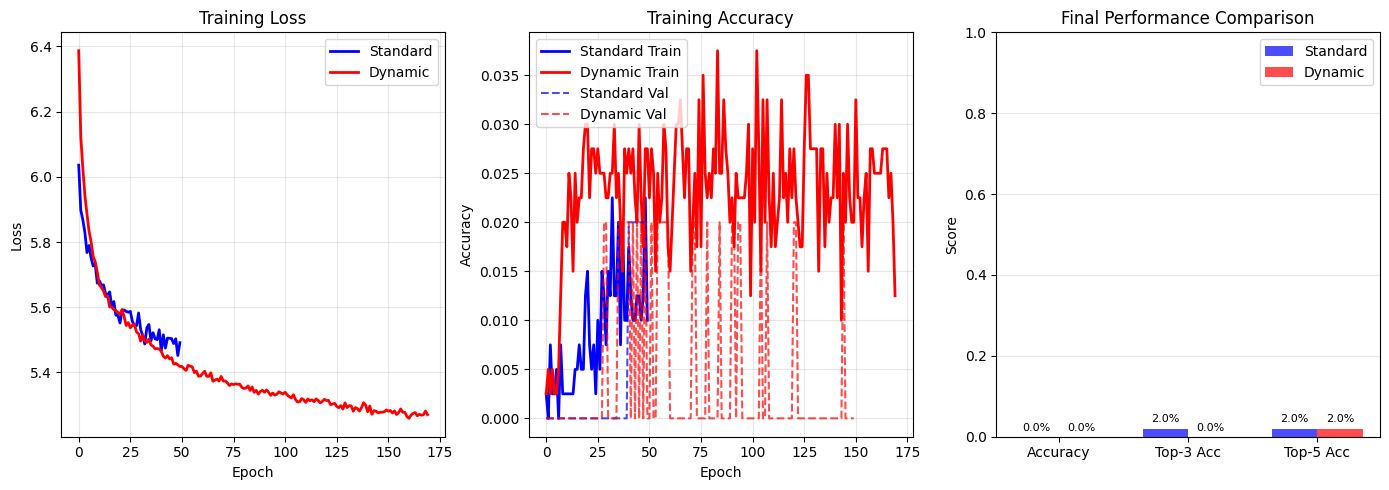

In [16]:
# Plot training curves
evaluator.plot_training_curves()

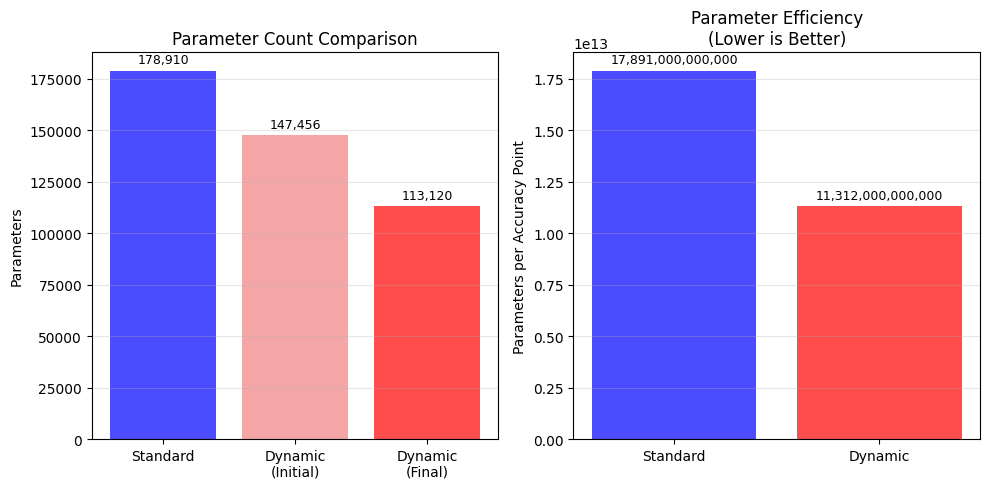

In [17]:
# Parameter efficiency comparison
evaluator.plot_parameter_efficiency()

## 8. Architecture Evolution Analysis <a id='8-architecture'></a>

Visualize how the Dynamic Transformer's architecture evolved during training.

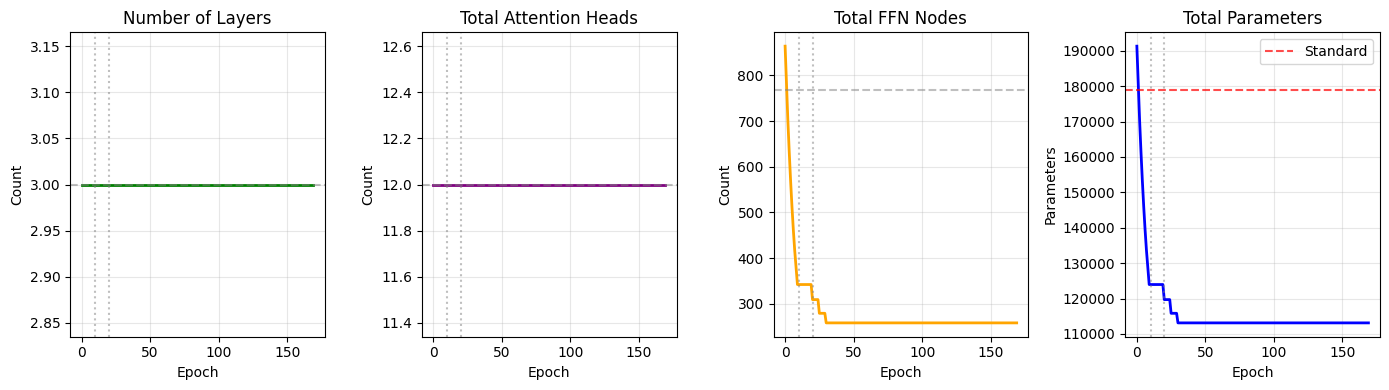

In [18]:
# Plot architecture evolution
evaluator.plot_architecture_evolution()

In [19]:
# Final architecture summary
print("\nFinal Dynamic Architecture:")
arch = dynamic_model.get_architecture_summary()
print(f"  Layers: {arch['num_layers']}")
print(f"  Heads per layer: {arch['heads_per_layer']}")
print(f"  FFN dim per layer: {arch['ffn_dim_per_layer']}")
print(f"  Total parameters: {arch['total_parameters']:,}")


Final Dynamic Architecture:
  Layers: 3
  Heads per layer: [4, 4, 4]
  FFN dim per layer: [86, 86, 86]
  Total parameters: 113,120


## 9. Health Monitoring Analysis <a id='9-health'></a>

Analyze the health scores (Cancer/Alzheimer) that track architecture stability.

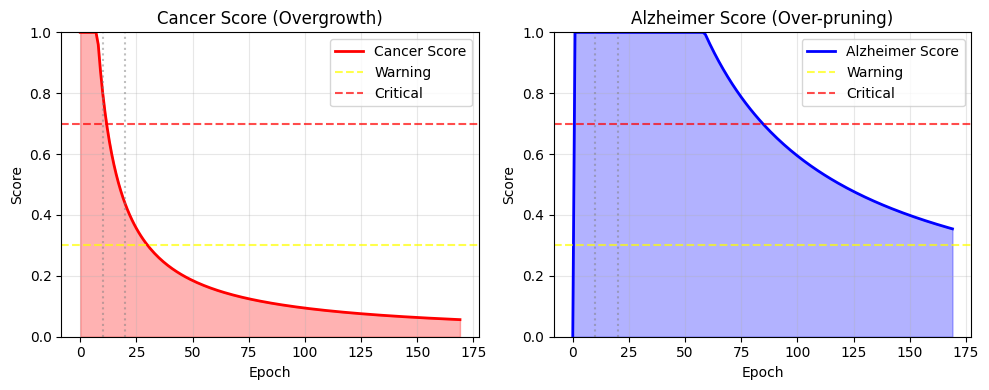

In [20]:
# Plot health scores
evaluator.plot_health_scores()

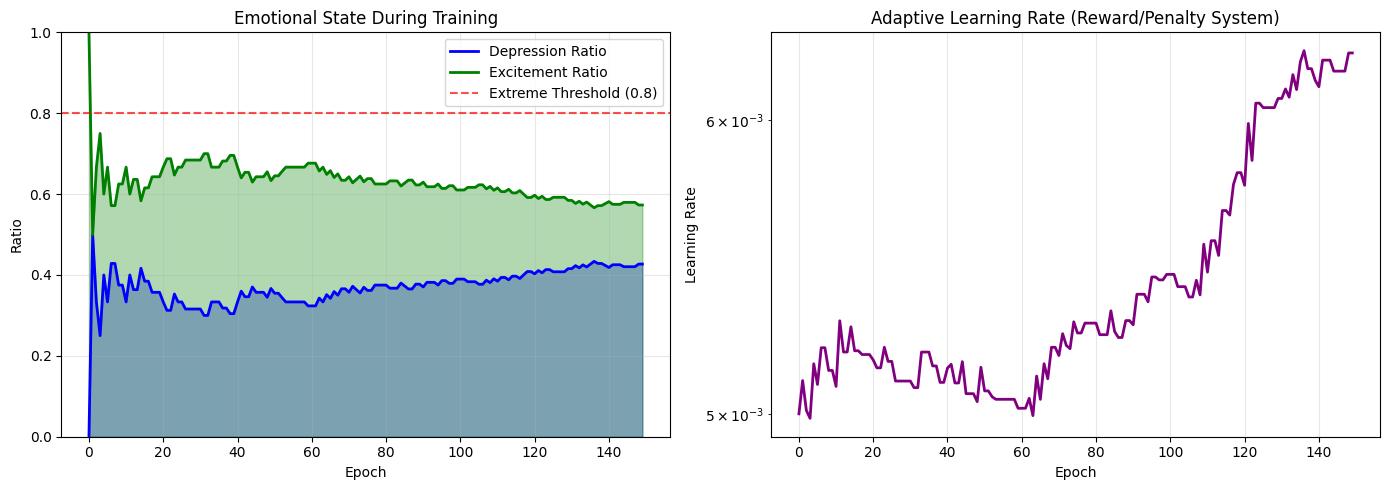

In [21]:
# Plot emotional state (depression/excitement ratios) over training
if 'depression_history' in dyn_history and len(dyn_history['depression_history']) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(len(dyn_history['depression_history']))
    
    # Emotional ratios over time
    ax1 = axes[0]
    ax1.plot(epochs, dyn_history['depression_history'], 'b-', label='Depression Ratio', linewidth=2)
    ax1.plot(epochs, dyn_history['excitement_history'], 'g-', label='Excitement Ratio', linewidth=2)
    ax1.axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='Extreme Threshold (0.8)')
    ax1.fill_between(epochs, dyn_history['depression_history'], alpha=0.3, color='blue')
    ax1.fill_between(epochs, dyn_history['excitement_history'], alpha=0.3, color='green')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Ratio')
    ax1.set_title('Emotional State During Training')
    ax1.legend()
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    # Learning rate history
    ax2 = axes[1]
    if 'learning_rate_history' in dyn_history and len(dyn_history['learning_rate_history']) > 0:
        lr_epochs = range(len(dyn_history['learning_rate_history']))
        ax2.plot(lr_epochs, dyn_history['learning_rate_history'], 'purple', linewidth=2)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Learning Rate')
        ax2.set_title('Adaptive Learning Rate (Reward/Penalty System)')
        ax2.set_yscale('log')
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'Learning rate history not available', 
                 ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Learning Rate History')
    
    plt.tight_layout()
    plt.show()
else:
    print("Emotional state history not available (reward/penalty system may not have been active)")

In [22]:
# Architecture change summary (including emotional state stats)
print("\nArchitecture Changes Summary:")
print(f"  Layers: +{dyn_history['layers_added']} / -{dyn_history['layers_removed']}")
print(f"  Attention Heads: +{dyn_history['heads_added']} / -{dyn_history['heads_removed']}")
print(f"  FFN Nodes: +{dyn_history['nodes_added']} / -{dyn_history['nodes_removed']}")
print(f"  Perturbations Applied: {dyn_history['perturbations_applied']}")

# Reward/Penalty System Summary
print("\nReward/Penalty System Summary:")
total_rewards = dyn_history.get('total_rewards', 0)
total_penalties = dyn_history.get('total_penalties', 0)
lr_resets = dyn_history.get('lr_reset_count', 0)

print(f"  Total Rewards: {total_rewards} (LR decreased when training improved)")
print(f"  Total Penalties: {total_penalties} (LR increased when training degraded)")
print(f"  LR Resets: {lr_resets} (reset to baseline on extreme states)")

if total_rewards + total_penalties > 0:
    depression_ratio = total_penalties / (total_rewards + total_penalties)
    excitement_ratio = total_rewards / (total_rewards + total_penalties)
    print(f"  Depression Ratio: {depression_ratio:.2%}")
    print(f"  Excitement Ratio: {excitement_ratio:.2%}")
    
    # Determine emotional health
    if depression_ratio > 0.8:
        emotional_health = "UNHEALTHY (Extreme Depression)"
    elif excitement_ratio > 0.8:
        emotional_health = "UNHEALTHY (Extreme Excitement)"
    elif 0.3 <= depression_ratio <= 0.7:
        emotional_health = "HEALTHY (Balanced)"
    else:
        emotional_health = "MODERATE"
    print(f"  Emotional Health: {emotional_health}")


Architecture Changes Summary:
  Layers: +0 / -0
  Attention Heads: +0 / -0
  FFN Nodes: +96 / -606
  Perturbations Applied: 10

Reward/Penalty System Summary:
  Total Rewards: 51 (LR decreased when training improved)
  Total Penalties: 38 (LR increased when training degraded)
  LR Resets: 1 (reset to baseline on extreme states)
  Depression Ratio: 42.70%
  Excitement Ratio: 57.30%
  Emotional Health: HEALTHY (Balanced)


## 10. Prediction Demo <a id='10-demo'></a>

Interactive demonstration of both models on sample inputs.

In [23]:
# Show prediction examples
evaluator.show_prediction_examples(X_test, y_test, n_examples=10, show_incorrect=True)


PREDICTION EXAMPLES

Cases where models DIFFER (10 shown):
--------------------------------------------------------------------------------

Example 1:
  Input: ايش الوقت الان...
  True:  مشمس
  Standard: استطيع المحادثة والاجابة على الاسئلة (2.49%) - WRONG
  Dynamic:  عدد الكواكب ثمانية (3.08%) - WRONG

Example 2:
  Input: هل تتكلم العربية...
  True:  نعم اتكلم العربية
  Standard: استطيع المحادثة والاجابة على الاسئلة (2.57%) - WRONG
  Dynamic:  عدد الكواكب ثمانية (3.04%) - WRONG

Example 3:
  Input: مع السلامة...
  True:  الله يسلمك
  Standard: استطيع المحادثة والاجابة على الاسئلة (2.52%) - WRONG
  Dynamic:  عدد الكواكب ثمانية (3.05%) - WRONG

Example 4:
  Input: هل سيكون الجو جميل غدا...
  True:  ممطر
  Standard: استطيع المحادثة والاجابة على الاسئلة (2.58%) - WRONG
  Dynamic:  عدد الكواكب ثمانية (3.05%) - WRONG

Example 5:
  Input: كيف الطقس غدا...
  True:  غدا سيكون غائم
  Standard: استطيع المحادثة والاجابة على الاسئلة (2.53%) - WRONG
  Dynamic:  عدد الكواكب ثمانية (3.09%) - WRONG


In [24]:
# Interactive test
def test_models(input_text):
    """Test both models on a custom input"""
    # Encode input
    input_ids = tokenizer.encode_input(input_text)
    input_batch = input_ids.reshape(1, -1)
    
    # Standard prediction
    std_probs = standard_model.predict_proba(input_batch)[0]
    std_pred = np.argmax(std_probs)
    std_conf = std_probs[std_pred]
    
    # Dynamic prediction
    dyn_probs = dynamic_model.predict_proba(input_batch)[0]
    dyn_pred = np.argmax(dyn_probs)
    dyn_conf = dyn_probs[dyn_pred]
    
    print(f"Input: {input_text}")
    print(f"Standard: {tokenizer.decode_output_label(std_pred)} ({std_conf:.2%})")
    print(f"Dynamic:  {tokenizer.decode_output_label(dyn_pred)} ({dyn_conf:.2%})")
    print()

# Test with some Arabic phrases
test_inputs = [
    "السلام عليكم",
    "ما اسمك",
    "كم الساعة",
    "كيف الطقس",
    "Hello كيف حالك"
]

print("\nInteractive Demo:")
print("=" * 50)
for text in test_inputs:
    test_models(text)


Interactive Demo:
Input: السلام عليكم
Standard: استطيع المحادثة والاجابة على الاسئلة (2.46%)
Dynamic:  عدد الكواكب ثمانية (3.07%)

Input: ما اسمك
Standard: استطيع المحادثة والاجابة على الاسئلة (2.54%)
Dynamic:  عدد الكواكب ثمانية (3.08%)

Input: كم الساعة
Standard: استطيع المحادثة والاجابة على الاسئلة (2.46%)
Dynamic:  عدد الكواكب ثمانية (3.12%)

Input: كيف الطقس
Standard: استطيع المحادثة والاجابة على الاسئلة (2.51%)
Dynamic:  عدد الكواكب ثمانية (3.11%)

Input: Hello كيف حالك
Standard: استطيع المحادثة والاجابة على الاسئلة (2.51%)
Dynamic:  عدد الكواكب ثمانية (3.10%)



## 11. Conclusions <a id='11-conclusions'></a>

In [25]:
# Generate and print comparison report
report = evaluator.generate_comparison_report()
print(report)

# Transformer Comparison Report

## Executive Summary

| Metric | Standard | Dynamic | Winner |
|--------|----------|---------|--------|
| Accuracy | 0.00% | 0.00% | Standard |
| Top-3 Accuracy | 2.00% | 0.00% | Standard |
| Perplexity | 428.28 | 397.97 | Dynamic |
| Parameters | 178,910 | 113,120 | Dynamic |
| Training Time | 181.6s | 283.0s | Standard |

## Performance Analysis

### Accuracy Improvement
- Absolute improvement: 0.00%
- Relative improvement: 0.0%

### Parameter Efficiency
- Standard: 17,891,000,000,000 params per accuracy point
- Dynamic: 11,312,000,000,000 params per accuracy point
- Efficiency gain: 36.8%

## Dynamic Architecture Changes

| Change Type | Added | Removed | Net |
|-------------|-------|---------|-----|
| Layers | 0 | 0 | 0 |
| Attention Heads | 0 | 0 | 0 |
| FFN Nodes | 96 | 606 | -510 |

## Health Monitoring

- **Cancer Score** (overgrowth): 5.61%
- **Alzheimer Score** (over-pruning): 35.44%
- **Overall Health**: 64.56%

## Conclusions

The Standard T

In [26]:
# Final summary
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

acc_diff = metrics.dynamic_accuracy - metrics.standard_accuracy
param_diff = metrics.dynamic_final_params - metrics.standard_params

print(f"\nAccuracy: Dynamic {'outperforms' if acc_diff > 0 else 'underperforms'} Standard by {abs(acc_diff):.2%}")
print(f"Parameters: Dynamic uses {abs(param_diff):,} {'more' if param_diff > 0 else 'fewer'} parameters")

if acc_diff > 0 and param_diff < 0:
    print("\nConclusion: Dynamic NN IMPROVES transformer - better accuracy with fewer parameters!")
elif acc_diff > 0:
    print("\nConclusion: Dynamic NN achieves better accuracy but uses more parameters.")
elif param_diff < 0:
    print("\nConclusion: Dynamic NN uses fewer parameters but with lower accuracy.")
else:
    print("\nConclusion: Standard transformer performs better on this task.")

print("\n" + "=" * 70)


FINAL SUMMARY

Accuracy: Dynamic underperforms Standard by 0.00%
Parameters: Dynamic uses 65,790 fewer parameters

Conclusion: Dynamic NN uses fewer parameters but with lower accuracy.



In [27]:
# Save models
import os
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

standard_model.save(f'{models_dir}/standard_transformer.npz')
dynamic_model.save(f'{models_dir}/dynamic_transformer.npz')
tokenizer.save(f'{models_dir}/tokenizer.json')

print(f"Models saved to {models_dir}/")

Models saved to ../models/
